# 11. Model Evaluation for Computer Vision

This notebook evaluates the fine-tuned ResNet-18 from notebook 10 using the existing local CIFAR-10 test set. It reports classification metrics and visualizes actual correct and incorrect predictions. It does not use synthetic labels or download another dataset.

**Prerequisite:** Run notebook 10 through its final save cell first. That produces artifacts/resnet18_cifar10_finetuned.pth.

## 1. Evaluation metrics

- **Accuracy:** fraction of all examples classified correctly.
- **Precision:** among predictions for a class, the fraction that truly belongs to that class.
- **Recall:** among true examples of a class, the fraction the model identifies.
- **F1-score:** harmonic mean of precision and recall.
- **Confusion matrix:** counts true classes (rows) versus predicted classes (columns); diagonal values are correct.
- **Per-class accuracy:** correct predictions divided by the number of true examples in each class. In single-label classification this equals that class's recall.
- **ROC-AUC:** measures ranking/separation from class probabilities. For CIFAR-10 we use multiclass one-vs-rest macro ROC-AUC.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             precision_recall_fscore_support, roc_auc_score)
DATA_ROOT = Path("data")
CIFAR_DIR = DATA_ROOT / "cifar-10-batches-py"
CHECKPOINT_PATH = Path("artifacts") / "resnet18_cifar10_finetuned.pth"
IMAGE_SIZE = 96
BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if not CIFAR_DIR.is_dir():
    raise FileNotFoundError(f"Local CIFAR-10 data not found: {CIFAR_DIR.resolve()}")
if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(f"Checkpoint not found at {CHECKPOINT_PATH.resolve()}. Run notebook 10 first.")
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])
test_dataset = datasets.CIFAR10(root=str(DATA_ROOT), train=False, download=False, transform=transform)
class_names = test_dataset.classes
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
model = models.resnet18(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, len(class_names))
state_dict = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model = model.to(device).eval()
print(f"Evaluating {len(test_dataset)} locally stored CIFAR-10 test images on {device}.")

Evaluating 10000 locally stored CIFAR-10 test images on cpu.


## 2. Run inference on the complete local test set

The official CIFAR-10 test set is separate from model training. We collect class probabilities for ROC-AUC and examples for error inspection.

In [3]:
true_labels = []
predicted_labels = []
probability_batches = []
with torch.inference_mode():
    for images, labels in test_loader:
        logits = model(images.to(device))
        probabilities = torch.softmax(logits, dim=1).cpu().numpy()
        predictions = probabilities.argmax(axis=1)
        true_labels.extend(labels.numpy().tolist())
        predicted_labels.extend(predictions.tolist())
        probability_batches.append(probabilities)
true_labels = np.asarray(true_labels)
predicted_labels = np.asarray(predicted_labels)
probabilities = np.concatenate(probability_batches, axis=0)
print(f"Predictions collected: {len(true_labels)}")

Predictions collected: 10000


## 3. Accuracy, precision, recall, F1-score, and ROC-AUC

Macro averages weight each class equally. Weighted averages account for each class's support. ROC-AUC uses predicted probabilities, not only the final predicted label.

In [4]:
accuracy = accuracy_score(true_labels, predicted_labels)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    true_labels, predicted_labels, average="macro", zero_division=0
)
roc_auc_macro = roc_auc_score(true_labels, probabilities, multi_class="ovr", average="macro")
print(f"Accuracy:            {accuracy:.4f}")
print(f"Precision (macro):   {precision_macro:.4f}")
print(f"Recall (macro):      {recall_macro:.4f}")
print(f"F1-score (macro):    {f1_macro:.4f}")
print(f"ROC-AUC (macro OVR): {roc_auc_macro:.4f}")
print("\nPer-class report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names, zero_division=0))

Accuracy:            0.8404
Precision (macro):   0.8416
Recall (macro):      0.8404
F1-score (macro):    0.8403
ROC-AUC (macro OVR): 0.9854

Per-class report:
              precision    recall  f1-score   support

    airplane       0.79      0.91      0.85      1000
  automobile       0.93      0.89      0.91      1000
        bird       0.83      0.77      0.80      1000
         cat       0.73      0.73      0.73      1000
        deer       0.81      0.80      0.80      1000
         dog       0.78      0.78      0.78      1000
        frog       0.88      0.89      0.88      1000
       horse       0.89      0.82      0.86      1000
        ship       0.90      0.89      0.90      1000
       truck       0.87      0.93      0.90      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



## 4. Confusion matrix and per-class accuracy

Read each row as the actual class and each column as the predicted class. Large off-diagonal entries identify frequent confusions.

In [5]:
cm = confusion_matrix(true_labels, predicted_labels, labels=np.arange(len(class_names)))
per_class_accuracy = np.diag(cm) / cm.sum(axis=1)
per_class_table = pd.DataFrame({"Class": class_names, "Per-class accuracy": per_class_accuracy})
per_class_table

,Class,Per-class accuracy
0,airplane,0.905
1,automobile,0.893
2,bird,0.767
3,cat,0.733
4,deer,0.798
5,dog,0.783
6,frog,0.886
7,horse,0.825
8,ship,0.889
9,truck,0.925


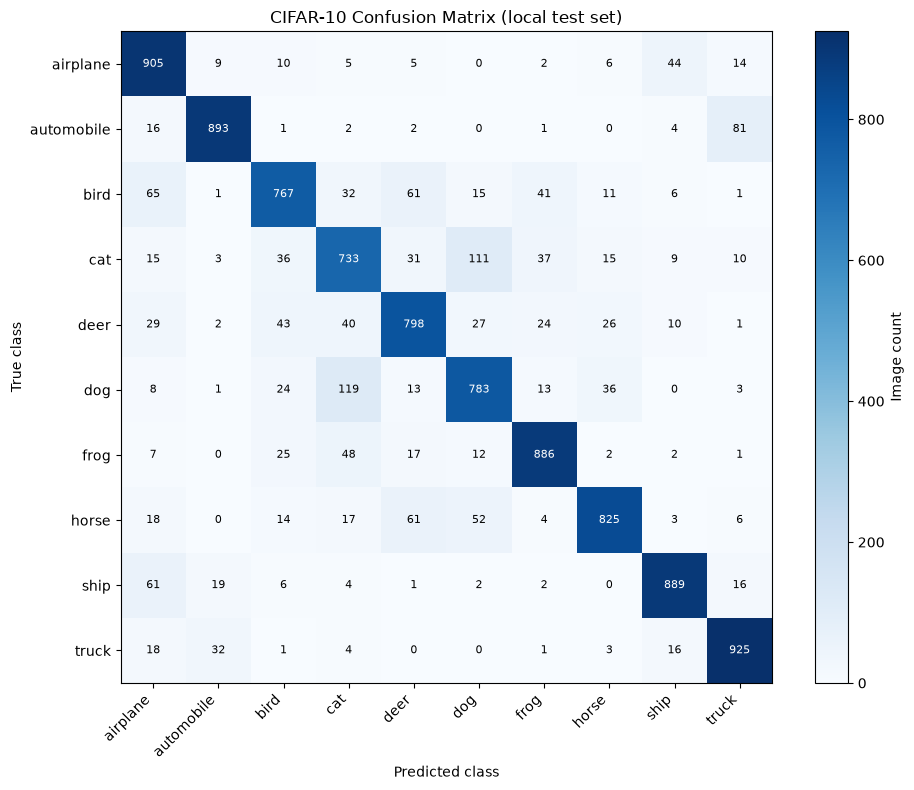

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(cm, cmap="Blues")
ax.set_xticks(np.arange(len(class_names)), labels=class_names, rotation=45, ha="right")
ax.set_yticks(np.arange(len(class_names)), labels=class_names)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("CIFAR-10 Confusion Matrix (local test set)")
fig.colorbar(image, ax=ax, label="Image count")
threshold = cm.max() / 2
for row in range(cm.shape[0]):
    for column in range(cm.shape[1]):
        ax.text(column, row, str(cm[row, column]), ha="center", va="center",
                color="white" if cm[row, column] > threshold else "black", fontsize=8)
fig.tight_layout()
plt.show()

## 5. Most confused class pairs

We rank off-diagonal counts from the confusion matrix. These are data-derived error patterns; use actual examples below to investigate their causes.

In [7]:
pair_rows = []
for true_id in range(len(class_names)):
    for predicted_id in range(len(class_names)):
        if true_id != predicted_id:
            pair_rows.append({
                "True class": class_names[true_id],
                "Predicted class": class_names[predicted_id],
                "Errors": int(cm[true_id, predicted_id]),
            })
most_confused = pd.DataFrame(pair_rows).sort_values("Errors", ascending=False).head(10).reset_index(drop=True)
most_confused

,True class,Predicted class,Errors
0,dog,cat,119
1,cat,dog,111
2,automobile,truck,81
3,bird,airplane,65
4,bird,deer,61
5,horse,deer,61
6,ship,airplane,61
7,horse,dog,52
8,frog,cat,48
9,airplane,ship,44


## 6. Visualize correct and incorrect predictions

These are actual test images from the local CIFAR-10 files. The helper reverses input normalization for display.

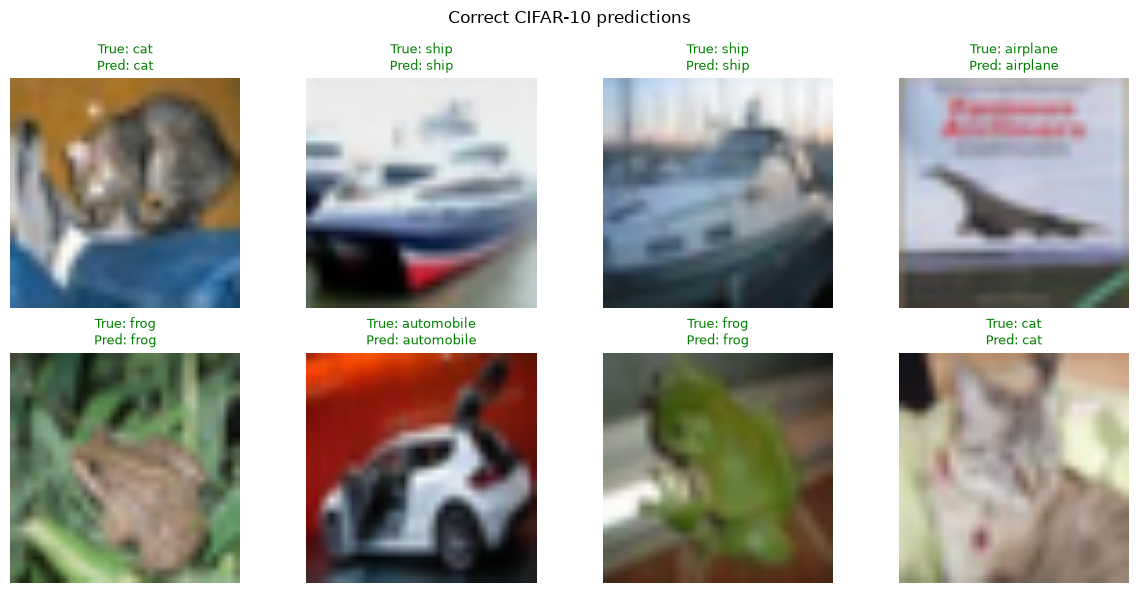

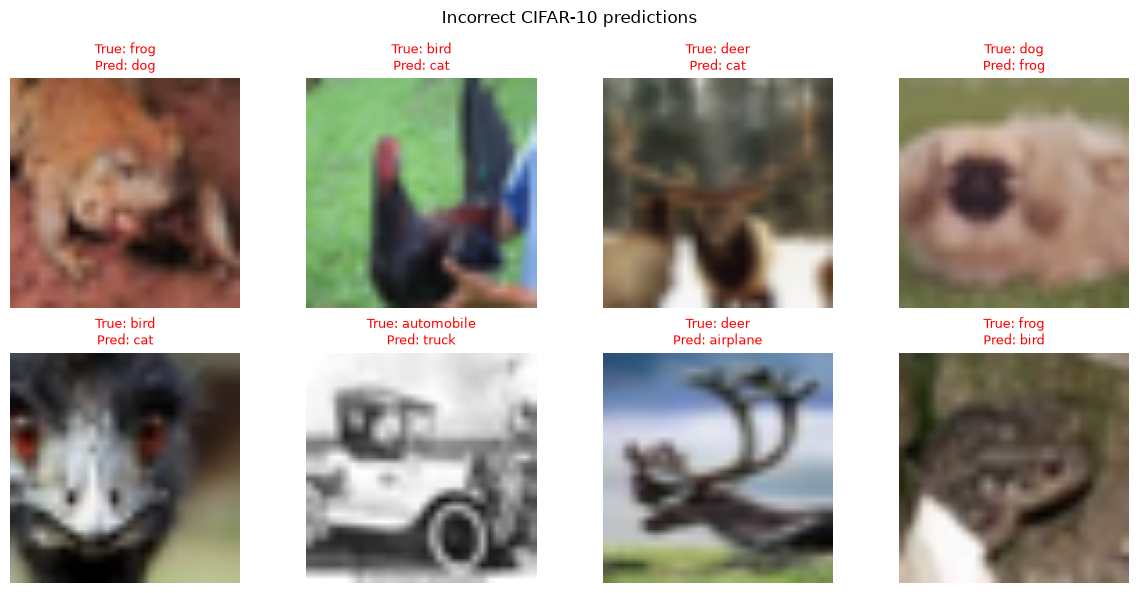

In [8]:
mean = torch.tensor((0.485, 0.456, 0.406)).view(3, 1, 1)
std = torch.tensor((0.229, 0.224, 0.225)).view(3, 1, 1)
def show_examples(indices, title, max_images=8):
    indices = list(indices)[:max_images]
    if not indices:
        print(f"No examples available for: {title}")
        return
    columns = 4
    rows = (len(indices) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(12, 3 * rows))
    axes = np.asarray(axes).reshape(-1)
    for ax, index in zip(axes, indices):
        normalized_image, _ = test_dataset[index]
        image = (normalized_image * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        actual = class_names[true_labels[index]]
        predicted = class_names[predicted_labels[index]]
        ax.imshow(image)
        ax.set_title(f"True: {actual}\nPred: {predicted}",
                     color="green" if actual == predicted else "red", fontsize=9)
        ax.axis("off")
    for ax in axes[len(indices):]:
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

correct_indices = np.flatnonzero(true_labels == predicted_labels)
incorrect_indices = np.flatnonzero(true_labels != predicted_labels)
show_examples(correct_indices, "Correct CIFAR-10 predictions")
show_examples(incorrect_indices, "Incorrect CIFAR-10 predictions")

## 7. Analyze major errors

For every major error, investigate the image evidence instead of guessing a cause from a metric alone.

1. **What went wrong?** State the true class and predicted class; note whether the object is small, occluded, or hard to see.
2. **Why might it have happened?** Check visual similarity, image quality, background, class balance, and confidence. Confirm the explanation against displayed examples.
3. **How could it be improved?** Consider representative examples, appropriate augmentation, resolution, targeted fine-tuning, or correcting data issues. Choose an intervention that addresses the observed cause.

The worksheet below does not invent causes without inspection.

In [ ]:
analysis_template = most_confused.copy()
analysis_template["What went wrong?"] = "Describe the observed image and prediction."
analysis_template["Why might it have happened?"] = "Inspect examples: similarity, scale, occlusion, background, or data issue?"
analysis_template["How could it be improved?"] = "Choose a change that addresses the verified cause."
analysis_template

## 8. Final takeaway

A single accuracy score cannot tell the full story. Use class-level precision, recall, F1, the confusion matrix, ROC-AUC, and actual prediction examples together. Treat each proposed cause as a hypothesis and verify it by inspecting local test images before changing the model or data pipeline.